### This notebook is used to calculate relative feature importances from the already calculated permutation feature importances (5 different train test split), produced with notebook p_27_feature_importance_analysis:

If pkl files not exist; you need to run feature_importance_analysis for the corresponding target_variable and model type (gbr or lightgbm)

* pkl files files can befound in ..\..\..\output_data\ML_analysis\feature_importances\
* they are named {target_var}_perm_imp_results_dataframes_5splits.pkl

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics
from numpy import mean
from numpy import std
import os

### Load data to get feature list:

In [2]:
nutrient_export_data = pd.read_csv('../../../output_data/input_ML_learning/median_cnp_export_abs_conc_and_rfr_and_basin_feat.csv').drop(columns='Unnamed: 0')

In [3]:

def create_input_ML(data, target_var):

    # create array with exported nutrient values, which are our target values, we want to predict 
    target = np.array(nutrient_export_data[target_var])


    # remove the labels from the features df:

    features = nutrient_export_data.drop(['HYBAS_ID', 'n_imbal', 'p_imbal', 'c_imbal', 'median_DOC_TOC_bioav', 'median_DIN', 'median_SRP'], axis = 1)
    #features = nutrient_export_data.filter(items=selected_features)

    #select columns by index: 
    features= features.iloc[:,0:43]
    features.columns

    # save feature list for later use:
    feature_list = list(features.columns)

    # convert to numpy array:
    #features = np.array(features)

    return target, features, feature_list

### 1. Set target variable and model type:

In [4]:
# select target_var: n_imbal, c_imbal, p_imbal, median_DIN, median_SRP or median_DOC_TOC_bioav
target_var = 'median_DOC_TOC_bioav'

#select model type: 'gbr' or 'lightgbm'
model_type = 'gbr'

In [5]:
# data:
data = nutrient_export_data
target, features, feature_list = create_input_ML(data = data, target_var = target_var)

In [6]:
import pickle

# Define the directory path
dir_path = f"../../../output_data/ML_analysis/feature_importances/{target_var}_{model_type}"

# Check if the directory exists, create it if it doesn't
#if not os.path.exists(dir_path):
#    os.makedirs(dir_path)

with open(f"{dir_path}/{target_var}_perm_imp_results_dataframes_5splits.pkl", 'rb') as f:
    perm_imp_results = pickle.load(f)

In [7]:
#perm_imp_results

### permutation feature importances are rescaled  so that the sum of each permutation is 100 %; this is done for all 70 permutations per model; subsequently all 5 models with different train test splits are combined to get the overall relative permutation feature importances:

1. extract importances of all 5 different models:

In [8]:
importance_list = [perm_result.importances for perm_result in perm_imp_results]

### Use a loop to caculate relative permutation feature importances for all five models (different train_test_splits):

* results are stored in a list "relative_perm_percentage_list" , which has exactly the same structure as the input file importance_list
* the permutation feature importances are now rescaled to percents

In [9]:
# create an empty list for the results:
relative_perm_percentage_list = []

for element in importance_list:
    sums = np.sum(np.abs(element), axis=0)

    # Calculate the relative percentage for each value
    relative_percentages = (element / sums) * 100
    
    relative_perm_percentage_list.append(relative_percentages)



In [10]:
relative_perm_percentage_list[0][:].min()

np.float64(-0.196394863013977)

### calculate mean values of relative permutation feature importances for all 33 features across 5 models (different data splits)

In [11]:
mean_values_relative_importances_5models = np.mean(relative_perm_percentage_list, axis = 2)


### calculate standard deviation values of relative permutation feature importances for all 33 features across 5 models (different data splits)

In [12]:
sd_values_relative_importances_5models = np.std(relative_perm_percentage_list, axis = 2)

In [13]:
table_ranking_relative_imp = pd.DataFrame({'rank':list(range(1, 34))})

for i,_ in enumerate(mean_values_relative_importances_5models):
    sorted_idx = mean_values_relative_importances_5models[i].argsort()
    # create a table containing ranks, mean value and std:
    table_ranking_relative_imp[f'feat_run_{i+1}'] = np.array(feature_list)[sorted_idx][::-1]
    table_ranking_relative_imp[f'mean_run_{i+1}'] =mean_values_relative_importances_5models[i][sorted_idx][::-1]
    table_ranking_relative_imp[f'std_run_{i+1}'] = sd_values_relative_importances_5models[i][sorted_idx][::-1]
    
    
table_ranking_relative_imp    

,rank,feat_run_1,mean_run_1,std_run_1,feat_run_2,mean_run_2,std_run_2,feat_run_3,mean_run_3,std_run_3,feat_run_4,mean_run_4,std_run_4,feat_run_5,mean_run_5,std_run_5
0,1,slp_dg_uav,27.917889,0.974581,slp_dg_uav,25.544286,1.143239,slp_dg_uav,25.398977,1.356723,slp_dg_uav,29.117848,1.518639,slp_dg_uav,29.318546,1.176748
1,2,sgr_dk_sav,10.970183,0.841799,ele_mt_uav,9.647481,0.849796,sgr_dk_sav,8.160991,0.994159,sgr_dk_sav,11.280777,1.050041,sgr_dk_sav,11.778504,0.940700
2,3,ele_mt_uav,9.857257,0.728990,sgr_dk_sav,7.218974,0.982500,ele_mt_uav,8.075166,0.798626,ele_mt_uav,9.897989,0.950646,ele_mt_uav,9.360741,0.961951
3,4,twi90,4.152567,0.426511,twi90,5.950840,1.115549,twi90,5.417942,0.676936,twi90,5.140965,0.887256,twi90,4.710749,0.639641
4,5,kar_pc_use,3.752394,0.411987,tmp_dc_uyr,5.098091,0.338935,UP_AREA,5.122493,0.591190,kar_pc_use,4.182798,0.733214,kar_pc_use,4.673794,0.650560
5,6,wet_pc_ug2,3.412624,0.455262,kar_pc_use,4.077519,0.549708,kar_pc_use,3.974131,0.473343,ero_kh_uav,3.116899,0.379888,wet_pc_ug2,3.532654,0.474813
6,7,tmp_dc_uyr,2.949164,0.307584,prm_pc_use,3.728736,0.380487,pre_mm_uyr,3.658302,0.465555,run_mm_syr,3.035846,0.670525,ero_kh_uav,3.408487,0.449733
7,8,pre_mm_uyr,2.863846,0.322850,crp_pc_use,3.508173,0.760990,tmp_dc_uyr,3.284245,0.311297,wet_pc_ug2,2.971851,0.680506,crp_pc_use,3.370734,0.584740
8,9,crp_pc_use,2.782937,0.411189,pre_mm_uyr,3.435440,0.452995,crp_pc_use,3.145269,0.698482,for_pc_use,2.930638,0.543378,pre_mm_uyr,2.937808,0.468782
9,10,pet_mm_uyr,2.759662,0.316907,snw_pc_uyr,3.301079,0.376242,ero_kh_uav,2.673286,0.392464,pre_mm_uyr,2.872703,0.514944,run_mm_syr,2.736552,0.515005


### combine all relative importances of all five models:

In [14]:
# combine importances of all 5 models (70values  * 5) in order to subsequently calculate overall mean values + standard deviations:
combined_relative_importances_5splits = np.concatenate(relative_perm_percentage_list, axis = 1)
len(combined_relative_importances_5splits)

33

### calculate standard deviation values of permutation feature importances for all 33 features across 5 models (different data splits)

In [15]:
std_values_relative_importances_5models_all = np.std(combined_relative_importances_5splits, axis = 1)

### calculate mean values of permutation feature importances for all 33 features across 5 models (different data splits)

In [16]:
mean_values_relative_importances_5models_all = np.mean(combined_relative_importances_5splits, axis = 1)
mean_values_relative_importances_5models_all

array([ 2.13700513e+00,  5.07461283e+00,  2.74595091e+01,  2.25606725e+00,
        3.12272704e+00,  5.91054734e-01,  9.53758949e-01,  2.64246148e+00,
        2.53034623e-01,  2.42783561e-01,  1.28238926e+00,  4.21846121e-01,
        9.36772710e+00,  9.88188559e+00,  3.06523459e+00,  3.15361960e+00,
        1.88873202e+00,  1.84905442e+00,  1.91535960e+00,  2.91309651e+00,
        3.47766566e-01, -3.29136767e-03,  1.46671363e+00,  2.93803480e-01,
        1.83301744e+00,  1.52760534e+00,  2.39132880e+00,  1.42183596e+00,
        6.91925999e-01,  4.13212733e+00,  2.86374160e+00,  1.28793663e+00,
        7.90899179e-01])

### Add to overall means to table:

In [17]:
sorted_ids_all = mean_values_relative_importances_5models_all.argsort()

table_ranking_relative_imp['feat_all_5runs'] = np.array(feature_list)[sorted_ids_all][::-1]
table_ranking_relative_imp['mean_all_5runs'] =  mean_values_relative_importances_5models_all[sorted_ids_all][::-1]
table_ranking_relative_imp['sd_all_5runs'] = std_values_relative_importances_5models_all[sorted_ids_all][::-1]
    


In [18]:
table_ranking_relative_imp

,rank,feat_run_1,mean_run_1,std_run_1,feat_run_2,mean_run_2,std_run_2,feat_run_3,mean_run_3,std_run_3,feat_run_4,mean_run_4,std_run_4,feat_run_5,mean_run_5,std_run_5,feat_all_5runs,mean_all_5runs,sd_all_5runs
0,1,slp_dg_uav,27.917889,0.974581,slp_dg_uav,25.544286,1.143239,slp_dg_uav,25.398977,1.356723,slp_dg_uav,29.117848,1.518639,slp_dg_uav,29.318546,1.176748,slp_dg_uav,27.459509,2.103264
1,2,sgr_dk_sav,10.970183,0.841799,ele_mt_uav,9.647481,0.849796,sgr_dk_sav,8.160991,0.994159,sgr_dk_sav,11.280777,1.050041,sgr_dk_sav,11.778504,0.940700,sgr_dk_sav,9.881886,2.070788
2,3,ele_mt_uav,9.857257,0.728990,sgr_dk_sav,7.218974,0.982500,ele_mt_uav,8.075166,0.798626,ele_mt_uav,9.897989,0.950646,ele_mt_uav,9.360741,0.961951,ele_mt_uav,9.367727,1.094560
3,4,twi90,4.152567,0.426511,twi90,5.950840,1.115549,twi90,5.417942,0.676936,twi90,5.140965,0.887256,twi90,4.710749,0.639641,twi90,5.074613,0.995347
4,5,kar_pc_use,3.752394,0.411987,tmp_dc_uyr,5.098091,0.338935,UP_AREA,5.122493,0.591190,kar_pc_use,4.182798,0.733214,kar_pc_use,4.673794,0.650560,kar_pc_use,4.132127,0.651906
5,6,wet_pc_ug2,3.412624,0.455262,kar_pc_use,4.077519,0.549708,kar_pc_use,3.974131,0.473343,ero_kh_uav,3.116899,0.379888,wet_pc_ug2,3.532654,0.474813,pre_mm_uyr,3.153620,0.557617
6,7,tmp_dc_uyr,2.949164,0.307584,prm_pc_use,3.728736,0.380487,pre_mm_uyr,3.658302,0.465555,run_mm_syr,3.035846,0.670525,ero_kh_uav,3.408487,0.449733,crp_pc_use,3.122727,0.709153
7,8,pre_mm_uyr,2.863846,0.322850,crp_pc_use,3.508173,0.760990,tmp_dc_uyr,3.284245,0.311297,wet_pc_ug2,2.971851,0.680506,crp_pc_use,3.370734,0.584740,tmp_dc_uyr,3.065235,1.224830
8,9,crp_pc_use,2.782937,0.411189,pre_mm_uyr,3.435440,0.452995,crp_pc_use,3.145269,0.698482,for_pc_use,2.930638,0.543378,pre_mm_uyr,2.937808,0.468782,wet_pc_ug2,2.913097,0.755697
9,10,pet_mm_uyr,2.759662,0.316907,snw_pc_uyr,3.301079,0.376242,ero_kh_uav,2.673286,0.392464,pre_mm_uyr,2.872703,0.514944,run_mm_syr,2.736552,0.515005,ero_kh_uav,2.863742,0.512971


In [19]:
# Define the directory path
dir_path = f"../../../output_data/ML_analysis/feature_importances/{target_var}_{model_type}"

table_ranking_relative_imp.to_csv(f"{dir_path}/{target_var}_ranking_relative_perm_imp_5splits.csv")

In [142]:
sorted_ids_all = mean_values_relative_importances_5models_all.argsort()


C:\Users\alexd\AppData\Local\Temp\ipykernel_44380\3146103370.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


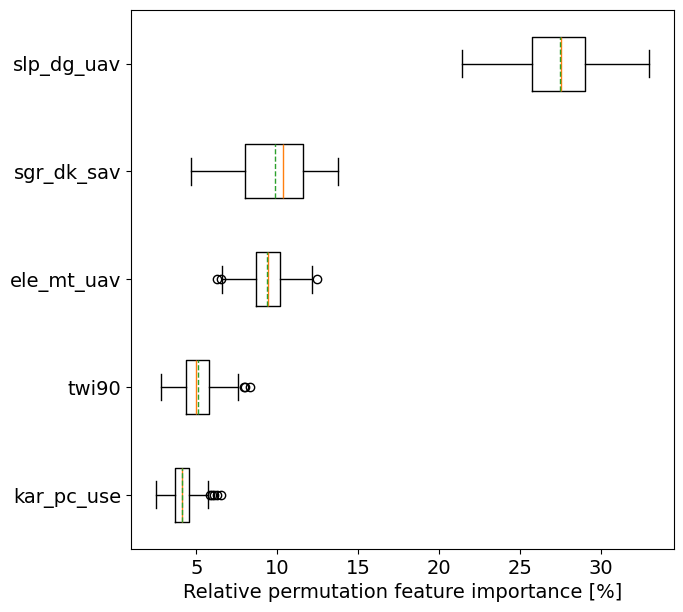

In [143]:
fig1, ax = plt.subplots(figsize=(7, 7))
plt.boxplot(
        combined_relative_importances_5splits[sorted_ids_all][-5:].T,
        vert=False,
        labels=np.array(feature_list)[sorted_ids_all][-5:],
        meanline=True,
        showmeans=True)
ax.tick_params(axis='both', labelsize=14)
plt.xlabel("Relative permutation feature importance [%]", fontsize = 14)
# Adjust the layout
plt.tight_layout
#plt.savefig(f"{dir_path}/permutation_importance/{target_var}_box_cox_perm_imp_mean_ranks_5mostimp.png")
plt.show()


In [144]:
y_values = {
    'median_DOC_TOC_bioav': 28.5,
    'median_DIN': 27.5,
    'median_SRP': 26.5,
    'c_imbal':28.5,
    'n_imbal':27.5,
    'p_imbal':29.5
}

C:\Users\alexd\AppData\Local\Temp\ipykernel_44380\1827407810.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


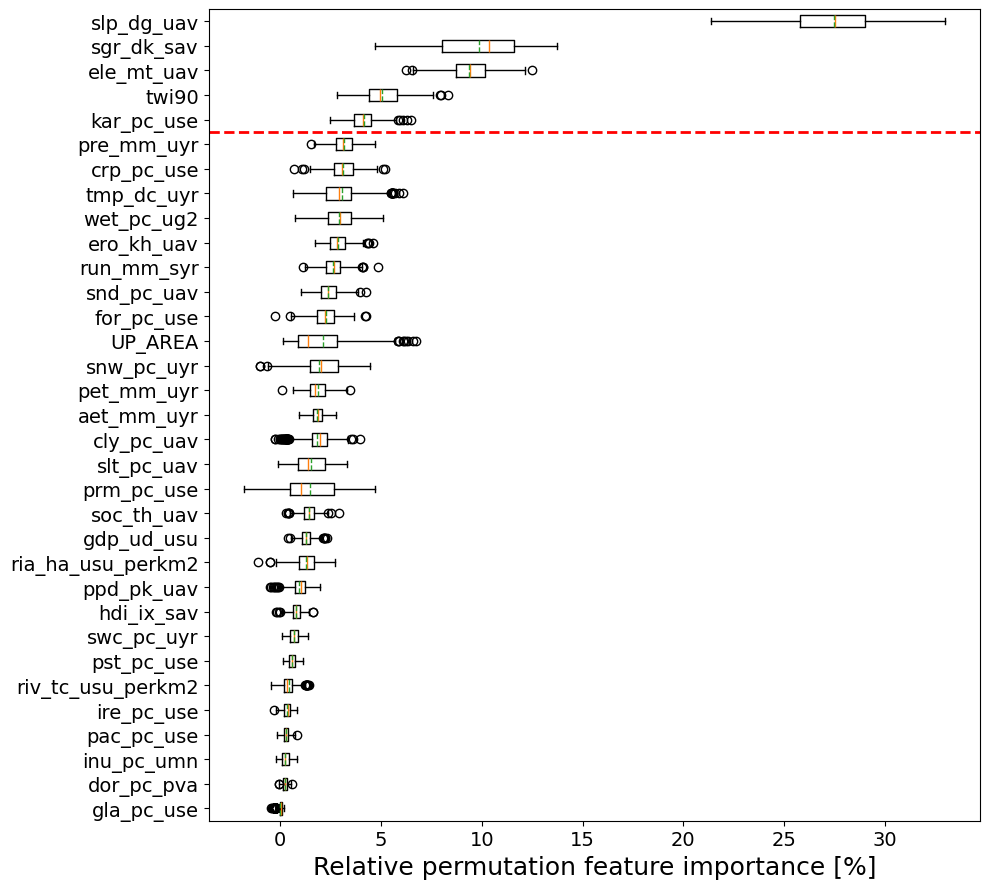

In [145]:
fig2, ax = plt.subplots(figsize=(10, 9))
plt.boxplot(
        combined_relative_importances_5splits[sorted_ids_all].T,
        vert=False,
        labels=np.array(feature_list)[sorted_ids_all],
        meanline=True,
        showmeans=True)
ax.tick_params(axis='both', labelsize=14)
y_value = y_values.get(target_var, 0)
ax.axhline(y = y_value, color = 'r', linestyle = '--', linewidth = 2)
#plt.title(f"Permutation Importance (test set) {target_var}_box_cox")
plt.xlabel("Relative permutation feature importance [%]", fontsize = 14)
ax.xaxis.label.set_size(18)
ax.yaxis.label.set_size(18)
# Adjust the layout
plt.tight_layout()
plt.show()

In [146]:
df_rankings = pd.DataFrame({'rank':  [1, 2,3,4]})
df_rankings[f'{target_var}'] = table_ranking_relative_imp['feat_all_5runs'][0:5]

In [149]:
df_rankings.to_csv(f"{dir_path}/ranking_cutoff_{target_var}_most_rel_imp_features.csv")

In [ ]:
df_rankings

,rank,median_SRP
0,1,ppd_pk_uav
1,2,pre_mm_uyr
2,3,for_pc_use
3,4,crp_pc_use


In [148]:
target_var

'median_DOC_TOC_bioav'